In [ ]:
!git clone https://github.com/ByteDance-Seed/Depth-Anything-3.git

In [ ]:
!pip install rosbags

In [ ]:
!pip install xformers torch\>=2 torchvision

In [ ]:
!pip install -e ./Depth-Anything-3

In [ ]:
!pip freeze | grep torch

In [ ]:
import glob, os, torch
from depth_anything_3.api import DepthAnything3
device = torch.device("cuda")
model = DepthAnything3.from_pretrained("depth-anything/DA3-LARGE-1.1")
model = model.to(device=device)

[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



config.json: 0.00B [00:00, ?B/s]

[INFO ] using MLP layer as FFN


model.safetensors:   0%|          | 0.00/1.64G [00:00<?, ?B/s]

In [ ]:
example_path = "/content/drive/MyDrive/lab/tabletop_imgs/extracted_images"
images = sorted(glob.glob(os.path.join(example_path, "*.png")))[:100]

In [ ]:
# import random
# images = random.sample(images, 10)
len(images)

100

In [ ]:
prediction = model.inference(
    images,
)
# prediction.processed_images : [N, H, W, 3] uint8   array
print(prediction.processed_images.shape)
# prediction.depth            : [N, H, W]    float32 array
print(prediction.depth.shape)
# prediction.conf             : [N, H, W]    float32 array
print(prediction.conf.shape)
# prediction.extrinsics       : [N, 3, 4]    float32 array # opencv w2c or colmap format
print(prediction.extrinsics.shape)
# prediction.intrinsics       : [N, 3, 3]    float32 array
print(prediction.intrinsics.shape)

[INFO ] Processed Images Done taking 1.5963952541351318 seconds. Shape:  torch.Size([100, 3, 378, 504])
[INFO ] Selecting reference view using strategy: saddle_balanced
[INFO ] Model Forward Pass Done. Time: 13.647515535354614 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0983419418334961 seconds
(100, 378, 504, 3)
(100, 378, 504)
(100, 378, 504)
(100, 3, 4)
(100, 3, 3)


Extracting 100 depth maps...
Saved side-by-side comparison images to '/content/drive/MyDrive/lab/depth_output/'


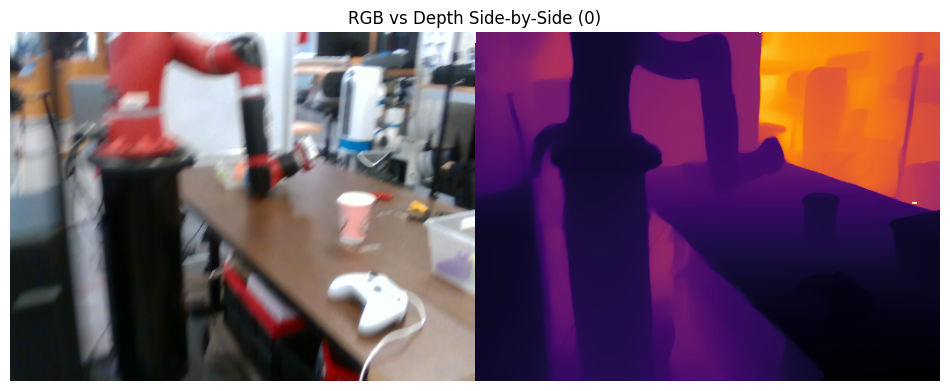

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

depths = prediction.depth
# Convert to numpy if it's a torch tensor
if hasattr(depths, 'cpu'):
    depths = depths.cpu().numpy()

print(f"Extracting {len(depths)} depth maps...")

out_dir = "/content/drive/MyDrive/lab/depth_output"
os.makedirs(out_dir, exist_ok=True)

for i, depth in enumerate(depths):
    # Normalize depth for visualization (0-255)
    depth_min = depth.min()
    depth_max = depth.max()

    if depth_max - depth_min > 1e-8:
        depth_normalized = (depth - depth_min) / (depth_max - depth_min) * 255.0
    else:
        depth_normalized = np.zeros_like(depth)

    depth_normalized = depth_normalized.astype(np.uint8)

    # Apply colormap (INFERNO is good for depth)
    depth_colormap = cv2.applyColorMap(depth_normalized, cv2.COLORMAP_INFERNO)

    # Load corresponding original image
    if i < len(images):
        original_img = cv2.imread(images[i])

        if original_img is not None:
            # Resize original image to match depth map dimensions
            h, w = depth_colormap.shape[:2]
            if original_img.shape[:2] != (h, w):
                original_img = cv2.resize(original_img, (w, h))

            # Create side-by-side comparison
            combined = np.hstack((original_img, depth_colormap))

            # Save side-by-side image
            filename = f"{out_dir}/comparison_{i:03d}.png"
            cv2.imwrite(filename, combined)
        else:
            print(f"Warning: Could not read image {images[i]}")
    else:
        print(f"Warning: No corresponding image found for depth map {i}")

print(f"Saved side-by-side comparison images to '{out_dir}/'")

# Display the first comparison
if len(depths) > 0:
    sample_file = f"{out_dir}/comparison_000.png"
    if os.path.exists(sample_file):
        plt.figure(figsize=(12, 6))
        plt.imshow(cv2.cvtColor(cv2.imread(sample_file), cv2.COLOR_BGR2RGB))
        plt.title("RGB vs Depth Side-by-Side (0)")
        plt.axis("off")
        plt.show()

In [ ]:
import plotly.graph_objects as go
import numpy as np
import cv2

def visualize_pointcloud_plotly(index=0, downsample=4):
    # 1. Get Data
    depth = prediction.depth[index]
    if hasattr(depth, 'cpu'): depth = depth.cpu().numpy()

    intrinsic = prediction.intrinsics[index]
    if hasattr(intrinsic, 'cpu'): intrinsic = intrinsic.cpu().numpy()

    image_path = images[index]
    color_bgr = cv2.imread(image_path)
    if color_bgr is None:
        print("Image not found")
        return
    color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)

    # Resize color to match depth dimensions
    h, w = depth.shape
    if color_rgb.shape[:2] != (h, w):
        color_rgb = cv2.resize(color_rgb, (w, h))

    # 2. Unproject Points
    fx, fy = intrinsic[0, 0], intrinsic[1, 1]
    cx, cy = intrinsic[0, 2], intrinsic[1, 2]

    # Create grid of coordinates
    xx, yy = np.meshgrid(np.arange(w), np.arange(h))

    # Downsample for browser performance
    xx = xx[::downsample, ::downsample].flatten()
    yy = yy[::downsample, ::downsample].flatten()
    z = depth[::downsample, ::downsample].flatten()
    colors = color_rgb[::downsample, ::downsample].reshape(-1, 3)

    # Calculate 3D coordinates
    x = (xx - cx) * z / fx
    y = (yy - cy) * z / fy

    # Format colors for Plotly: ['rgb(r,g,b)', ...]
    color_strs = [f'rgb({c[0]},{c[1]},{c[2]})' for c in colors]

    # 3. Plot
    fig = go.Figure(data=[go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=2,
            color=color_strs,
            opacity=1.0
        )
    )])

    # Adjust layout for better viewing
    fig.update_layout(
        title=f"Point Cloud Visualization - Image {index}",
        scene=dict(
            xaxis=dict(title='X', visible=False),
            yaxis=dict(title='Y', visible=False, autorange="reversed"), # Image Y is down
            zaxis=dict(title='Z', visible=False),
            aspectmode='data'
        ),
        margin=dict(l=0, r=0, b=0, t=30)
    )
    fig.show()

# Visualize the first image
visualize_pointcloud_plotly(index=50, downsample=5)